<font size=5  color=#12d0ff> <b>[LELEC2900] - Signal Processing (2025-2026) <br><br> 
Python01 - Basic Properties of Sampling</b>  </font> <br><br><br>

<font size=4>
Prof. L. Vandendorpe<br>
Prof. G. Bianchin (replacing Prof. L. Jacques)<br>
Dr. G. Monnoyer (replacing Prof. L. Jacques)
<br><br>
Anne-Sophie Collin (anne-sophie.collin@uclouvain.be)<br> 
Edouard Couplet (edouard.couplet@uclouvain.be)<br>
Florian Quatresooz (florian.quatresooz@uclouvain.be) <br>
Mathieu Reniers (mathieu.reniers@uclouvain.be)<br>
Audrey Vermeulen (audrey.vermeulen@uclouvain.be)<br>
<br>
</font>

<font size="5" color="#12a0ff"><b>Useful Documentation</b></font><br>

Throughout this notebook, the following links may be useful:
- <a href="https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html"><samp>numpy.fft.fft<samp></a>
- <a href="https://numpy.org/devdocs/reference/generated/numpy.fft.fftfreq.html"><samp>numpy.fft.fftfreq<samp></a>
- <a href="https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html"><samp>numpy.random.normal<samp></a>
- <a href="https://numpy.org/devdocs/reference/generated/numpy.convolve.html"><samp>numpy.convolve<samp></a>
- <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.windows.triang.html#scipy.signal.windows.triang"><samp>scipy.signal.windows.triang<samp></a>

We encourage you to become familiar with browsing the documentation and finding the information you need (rather than asking your favorite chatbot), as this skill will be very useful for the evaluation 😉.


<font size=5 color=#12a0ff> <b>1. Discrete Fourier Transform</b> </font> <br> 

<font size=5 color=#12a0ff> <i>1.1 Recovering Heart beat from ECG</i> </font> <br> 

An Electrocardiogram (ECG) is a recording of the electrical activity of the heart. This signal is recorded during a nonivasive procedure where electrodes are placed on the chest. By computing the Fourier transform of an ECG, the hearbeat of a patient can be recovered. 

For this exercise, 
<ol>
   <li> Import the ECG signals of <br>
       (a) a healthy patient (ECG_Normal.csv - with a sampling frequency of 500 Hz), <br>
       (b) a patient with arrythmia (ECG_Arrhythmia.csv - with a sampling frequency of 360 Hz). <br>
       Arrhythmia is a disease implying an irregular heartbeat pattern. We strongly suggest you to use the <samp>read_csv</samp> function from the pandas library;
     
   <li> Plot the signal in the time domain and in the frequency domain (by computing a Fourier transform). We suggest you to use the <samp>fft</samp> function from the <samp>numpy.ftt</samp> library. Compare the Fourier transforms of both signals. Are they similar?
   <li> By recovering the frequency of highest amplitude, deduce the value of the heartbeat frequency (Hz) and the number of beats per minute for each patient.  
</ol>

In [1]:
#---------------------------------------------------------------------------
#TO RUN
#We provide you two funtions to plot a time signal (with/without its DFT) in
#the make_graphs file. Open the file to read the function's description if 
#you want to use them.
#---------------------------------------------------------------------------

%load_ext autoreload
%autoreload 2
import numpy as np
from make_graphs import plotSignal, plotSignalAndDft

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7996/4082862976.py:12: SyntaxWarning: invalid escape sequence '\s'
  signals['Normal']   = {'fs': 500, 'signal': pd.read_csv(root +'/Data/ECG_Normal.csv', sep="\s+", header=None)}
/tmp/ipykernel_7996/4082862976.py:13: SyntaxWarning: invalid escape sequence '\s'
  signals['Arythmia'] = {'fs': 360, 'signal': pd.read_csv(root +'/Data/ECG_Arrhythmia.csv', sep="\s+", header=None)}


----------  Patient : Normal ----------
[0.03974137 0.03974138 0.0397414  ... 2.83698564 6.75906633 2.31417107]
[0.03974137 0.03974138 0.0397414  ... 0.03974144 0.0397414  0.03974138]


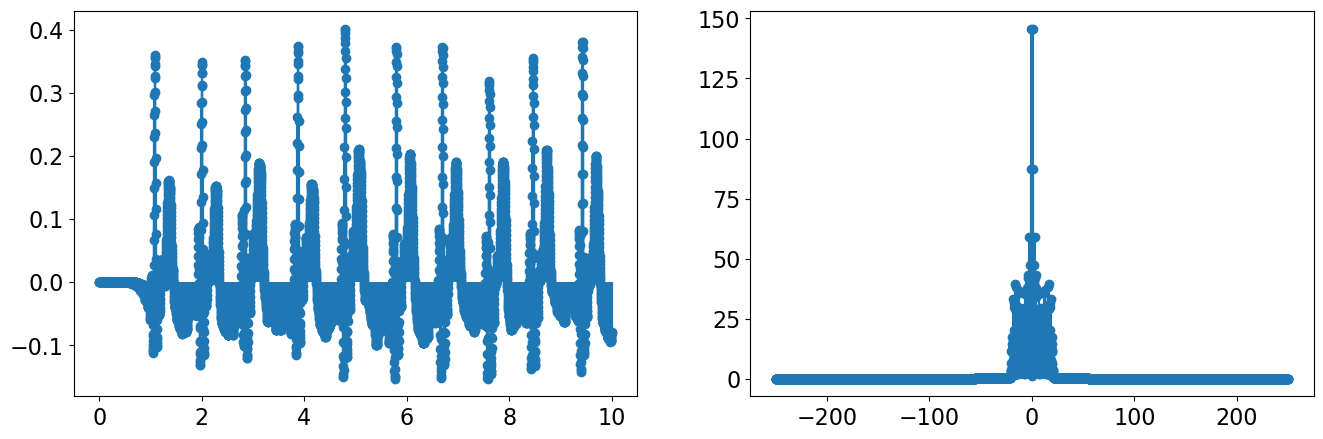

Cardiac rythm 1.1 Hz
----------  Patient : Arythmia ----------
[8.76828917e-03 8.76829106e-03 8.76829632e-03 ... 1.97749784e+01
 1.48512464e+01 2.09291516e+01]
[0.00876829 0.00876829 0.0087683  ... 0.0087683  0.0087683  0.00876829]


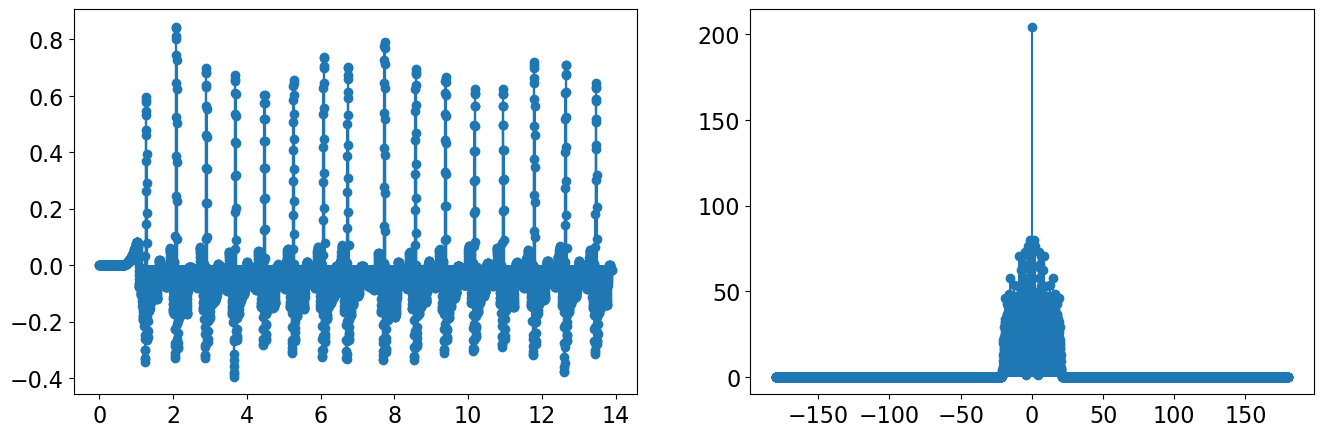

Cardiac rythm 1.224 Hz


In [2]:
#---------------------------------------------------------------------------
#TO COMPLETE
#---------------------------------------------------------------------------

import pandas as pd
import os
root = os.getcwd() # Your folder location (if needed...)

# 1. Import the signals 
# Example of code to import the signals and store them in a dictionnary. You may have to adapt file path. 
signals = {}
signals['Normal']   = {'fs': 500, 'signal': pd.read_csv(root +'/Data/ECG_Normal.csv', sep="\s+", header=None)}
signals['Arythmia'] = {'fs': 360, 'signal': pd.read_csv(root +'/Data/ECG_Arrhythmia.csv', sep="\s+", header=None)}

# 2. Plot signals in time and frequency domains.
for patient in signals: 
    print("-"*10, " Patient :", patient, "-"*10)
    
    ecg = signals[patient]['signal'].values.flatten()
    ft = np.abs(np.fft.fft(ecg))
    print(ft[2500:5000])
    ft = np.array([ft[2500:5000], ft[0:2500]]).flatten()
    print(ft)
    
    time = np.linspace(0, len(ecg) / signals[patient]['fs'], num = len(ecg))
    freq = np.linspace(-1*signals[patient]['fs']/2, signals[patient]['fs']/2, num = len(ft))
    
    plotSignalAndDft(time, ecg, freq, ft)
    
    # 3. Deduce heart beat frequency and number of beats per minute.
    
    ft[2500] = 0
    
    jaaj = abs(np.argmax(ft) - 2500)
    print("Cardiac rythm " + str(((jaaj)/2500) * signals[patient]['fs']/2) + " Hz")
    

<font size=5 color=#12a0ff> <i>1.2  Zero padding and Zero insertion</i> </font> <br> 

The objective of this exercise is to study the impact of zero padding and zero insertion on the discrete Fourier transform.

Perform and study impact of the following modification on the ECG recorded on the healthy patient (without arrythmia),
<ol>
   <li> Given that the original signal contains N samples, append N zeros to the end of the ECG signal. Display the FFT of the new signal of size 2N; 
   <li> Insert one zero between every element of the original ECG. Display the FFT of the new signal of size 2N.
</ol>

----------  Impact of zero insertion ----------


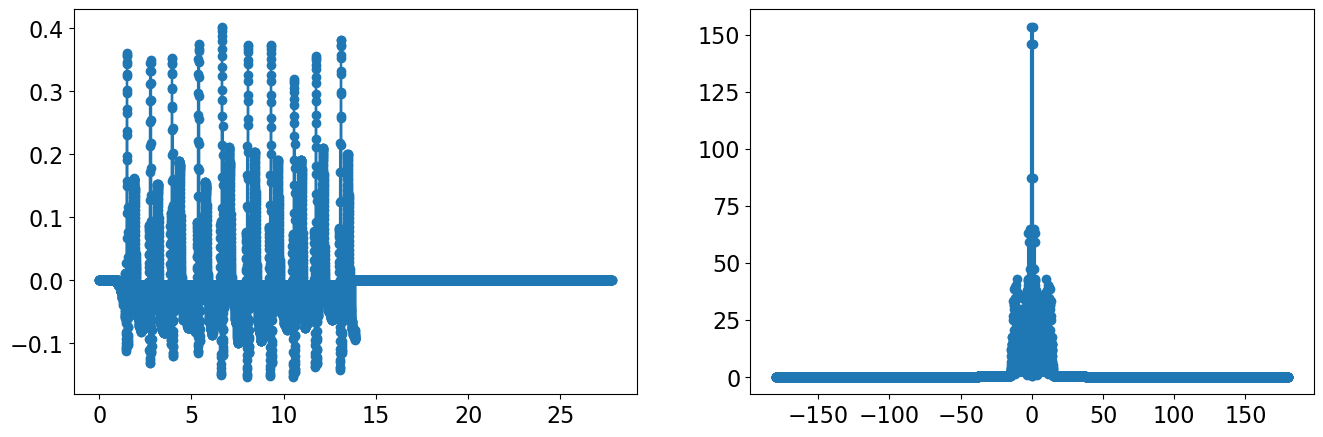

----------  Impact of zero padding ----------


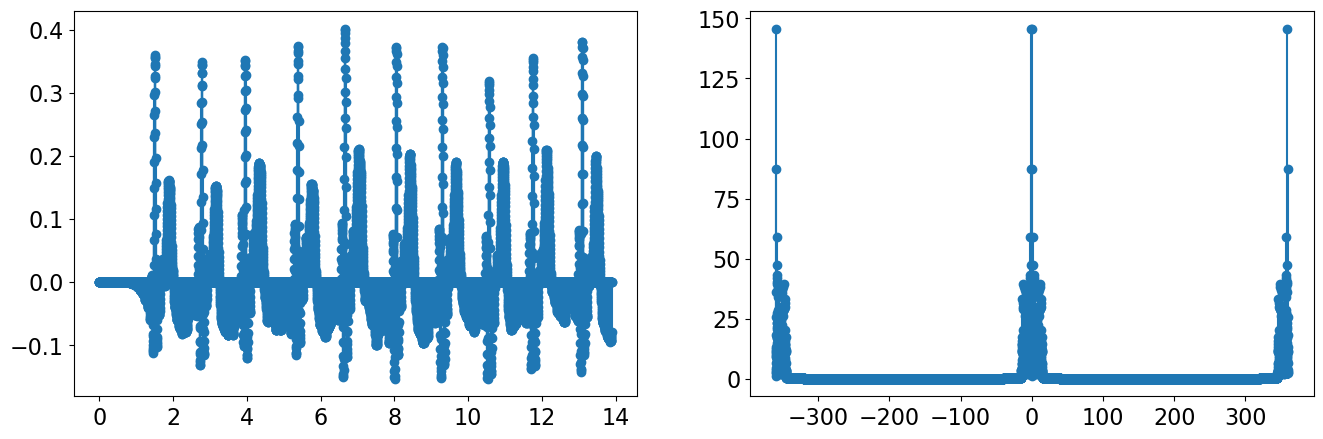

In [3]:
#---------------------------------------------------------------------------
#TO COMPLETE
#---------------------------------------------------------------------------

N = len(signals['Normal']['signal'].values.flatten())

print("-"*10, " Impact of zero insertion", "-"*10)
# coding tip: 
# a. create an array of dimension (2N, 1) filled with zeros
# b. change the begining of the array with newArray[0:N] = ...
array1 = np.zeros(2*N)
array1[0:N] = signals['Normal']['signal'].values.flatten()
ft = np.abs(np.fft.fft(array1))
ft = np.array([ft[len(ft)//2:len(ft)], ft[0:len(ft)//2]]).flatten()

time = np.linspace(0, 2*N / signals[patient]['fs'], num = 2*N)
freq = np.linspace(-1*signals[patient]['fs']/2, signals[patient]['fs']/2, num = len(ft))
    
plotSignalAndDft(time, array1, freq, ft)


print("-"*10, " Impact of zero padding", "-"*10)
# coding tip: 
# a. create an array of dimension (2N, 1) filled with zeros
# b. change one over two samples with newArray[::2] = ...
array2 = np.zeros(2*N)
array2[::2] = signals['Normal']['signal'].values.flatten()
ft = np.abs(np.fft.fft(array2))
ft = np.array([ft[len(ft)//2:len(ft)], ft[0:len(ft)//2]]).flatten()

time = np.linspace(0, N / signals[patient]['fs'], num = 2*N)
freq = np.linspace(-1*signals[patient]['fs'], signals[patient]['fs'], num = len(ft))
    
plotSignalAndDft(time, array2, freq, ft)

<br>

<font size=5 color=#12a0ff> <b>2. Decimation and interpolation </b> </font> <br> <br>

<font size=5 color=#12a0ff> <i>2.1 A bit of theory</i> </font>


Multirate systems are fundamental in the design of modern signal processing techniques. In order to design such systems, one must be able to convert signals at higher or lower sample rates. With this aim in view, the concepts of interpolation and decimation will be addressed during the lectures: 


- <b>Interpolation</b> is used for converting a signal at a higher sample rate. The basic implementation of an interpolation filter (of factor $I$) consists in two successive steps:
    - inserting $I-1$ zeros between the samples of the original signal
    - Applying a low-pass filter on the signal.

    <img src="Imgs/image_4.png" width = "400">

- <b>Decimation</b> is used for converting a signal at a lower sample rate. The basic implementation of a decimation filter (of factor $D$) consists in two successive steps:

    - applying a low pass filter on the original signal (to avoid aliasing).
    - removing $D-1$ samples for every block of $D$ succesive samples.

    <img src="Imgs/image_5.png" width = "400">
    <br>
    
<font size=5 color=#12a0ff> <i>2.2 Generate a sine wave</i> </font>

The objective of this exercise is to apply the operations of decimation and interpolation on a simple sine function, and to observe their effects in the spectral domain.

We consider a continuous sine function of unit amplitude and with a frequency of $100$ Hz. This function is corrupted by a zero mean Gaussian noise of variance $0.05$. One records noisy measurements of this signal during $0.04$ seconds with a sampling frequency of $10^4$ Hz. Generate a vector x containing these measured values. Plot the resulting sequence in the time domain as well as its DFT (in magnitude).

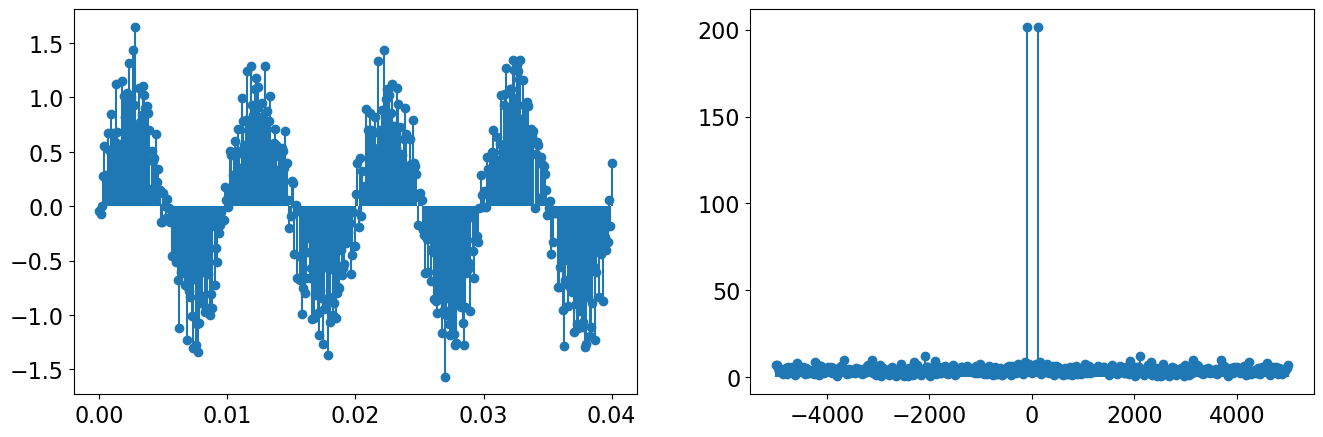

In [4]:
#---------------------------------------------------------------------------
#TO COMPLETE
#---------------------------------------------------------------------------
def func(array):
    return np.sin(2*np.pi*100*array) + np.random.normal(loc=0, scale=np.sqrt(0.05), size=len(array))
# Generate the sine wave 

# Plot the signal in the time and frequency domain
duration = 0.04
f_s = 1e4
time = np.linspace(0, duration, num=int(duration*f_s))

x = func(time)

ft = np.abs(np.fft.fft(x))
ft = np.array([ft[len(ft)//2:len(ft)], ft[0:len(ft)//2]]).flatten()
freq = np.linspace(-f_s//2, f_s//2, num=len(ft))


plotSignalAndDft(time, x, freq, ft)

<font size=5 color=#12a0ff> <i>2.3 Standard decimation and interpolation</i> </font>

In order to simplify the sinusoidal storage or transmission, we decimate signal $x$ by $M=10$, after performing a proper lowpass filtering to minimize aliasing distortion. 

Since digital filters have not been covered yet in this course, the low-pass filter that we will implemented here is arbitrarily chosen. We here select a moving average filter of order 20 since this filter is easy to implement.
As a reminder, the impulse response of a moving average filter of order $N$ is given by 
$$h[n] = \frac{1}{N}  ~\text{for}~ n = 0,...,N-1.$$

    
Plot the decimated signal in the frequency domain as well as its DFT (in magnitude).


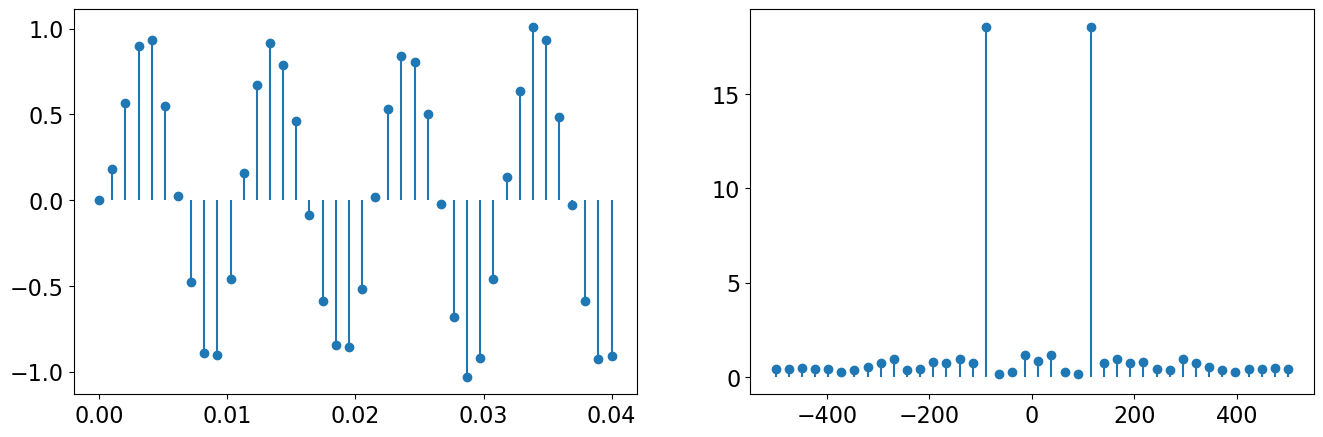

In [5]:
#---------------------------------------------------------------------------
#TO COMPLETE
#---------------------------------------------------------------------------

# Generate the impulse response of the filter and convolve with the sine wave
N         = 20
h         = np.ones(N,)/N
xFiltered = np.convolve(x, h)[0:len(x)]
xFiltered = xFiltered[::10]

ft = np.abs(np.fft.fft(xFiltered))
ft = np.concatenate(np.array_split(ft, 2)[::-1])

time = np.linspace(0, duration, num=int(duration*f_s//10))
freq = np.linspace(-f_s//20, f_s//20, num=len(ft))


plotSignalAndDft(time, xFiltered, freq, ft)

# Plot the signal in the time and frequency domain

Expand the rate back to its original value by introducing $(M-1)$ zeros between each two consecutive subsamples.
   
Plot the resulting sequence in the time domain as well as its DFT (in magnitude).

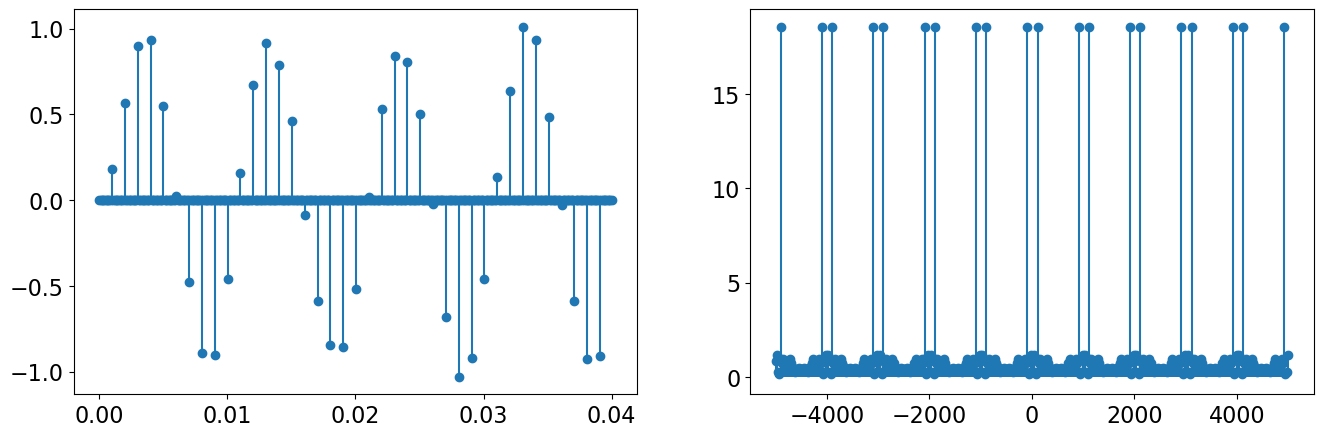

In [6]:
#---------------------------------------------------------------------------
#TO COMPLETE
#---------------------------------------------------------------------------

xFilteredUp = np.zeros(10*len(xFiltered))
xFilteredUp[::10] = xFiltered

ft = np.abs(np.fft.fft(xFilteredUp))
ft = np.concatenate(np.array_split(ft, 2)[::-1])

time = np.linspace(0, duration, num=int(duration*f_s))
freq = np.linspace(-f_s//2, f_s//2, num=len(ft))


plotSignalAndDft(time, xFilteredUp, freq, ft)

Remove the spectral repetitions induced by the inserted zeros by means of a low pass filter. Make use of a triangular filter of length $20$ (using the function <samp>scipy.signal.triang</samp> or <samp>scipy.signal.windows.triang</samp>, depending on your Python version).

In [7]:
import scipy as sc

help(sc.signal.windows.triang)

Help on function triang in module scipy.signal.windows._windows:

triang(M, sym=True)
    Return a triangular window.

    Parameters
    ----------
    M : int
        Number of points in the output window. If zero, an empty array
        is returned. An exception is thrown when it is negative.
    sym : bool, optional
        When True (default), generates a symmetric window, for use in filter
        design.
        When False, generates a periodic window, for use in spectral analysis.

    Returns
    -------
    w : ndarray
        The window, with the maximum value normalized to 1 (though the value 1
        does not appear if `M` is even and `sym` is True).

    See Also
    --------
    bartlett : A triangular window that touches zero

    Examples
    --------
    Plot the window and its frequency response:

    >>> import numpy as np
    >>> from scipy import signal
    >>> from scipy.fft import fft, fftshift
    >>> import matplotlib.pyplot as plt

    >>> window = signal.wi

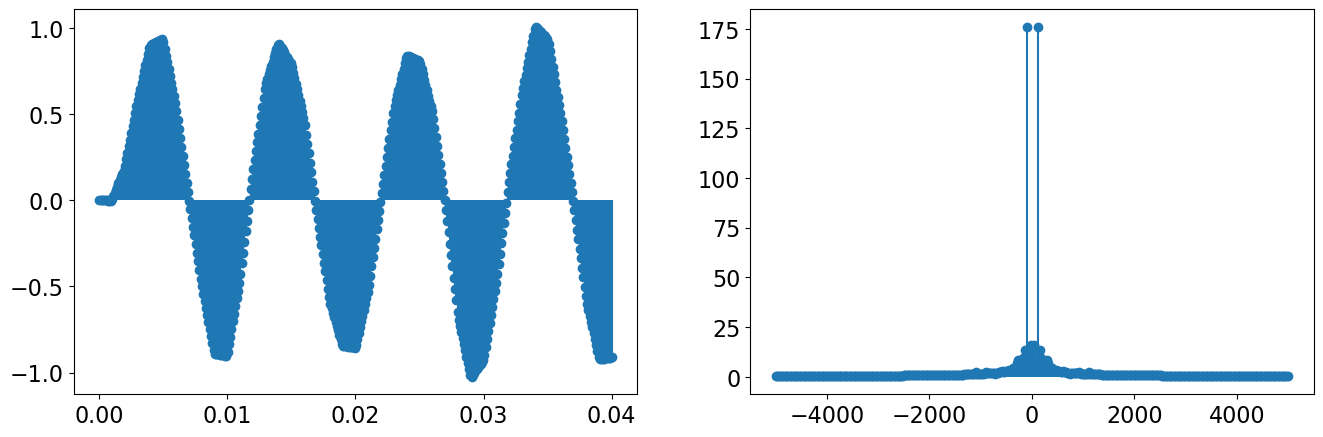

In [8]:
filt = sc.signal.windows.triang(M=20)

xFilteredDown = np.convolve(xFilteredUp, filt)[0:len(xFilteredUp)]

ft = np.abs(np.fft.fft(xFilteredDown))
ft = np.concatenate(np.array_split(ft, 2)[::-1])

plotSignalAndDft(time, xFilteredDown, freq, ft)

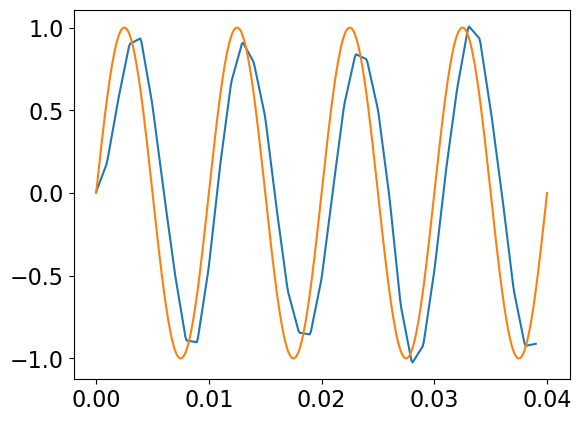

In [17]:
import matplotlib.pyplot as plt

y = np.sin(2*np.pi*100*time)

diff = y - xFilteredDown

plt.plot(time[:len(time)-10], xFilteredDown[10:])
plt.plot(time, y)
plt.show()